In [4]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split


In [5]:
data= pd.read_csv("C:/Users/USER/Desktop/mental_health_risk_dataset.csv")

In [6]:
data.head()

,age,gender,marital_status,education_level,employment_status,sleep_hours,physical_activity_hours_per_week,screen_time_hours_per_day,social_support_score,work_stress_level,...,depression_score,stress_level,mood_swings_frequency,concentration_difficulty_level,panic_attack_history,family_history_mental_illness,previous_mental_health_diagnosis,therapy_history,substance_use,mental_health_risk
0,56,Other,Single,Bachelor,Unemployed,8.6,2.8,9.6,7,10,...,4,8,8,3,1,0,1,1,1,1
1,47,Male,Single,Bachelor,Unemployed,4.5,2.7,3.0,10,6,...,7,4,9,3,0,0,0,0,0,0
2,56,Female,Divorced,Bachelor,Student,3.1,14.1,7.2,10,5,...,3,1,4,2,1,1,1,1,1,2
3,59,Other,Married,Bachelor,Employed,7.0,0.5,10.3,2,10,...,8,5,2,5,1,1,0,1,1,2
4,58,Male,Single,High School,Self-Employed,5.1,2.5,1.2,8,1,...,8,3,3,1,0,0,1,0,1,0


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 25 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   age                               25000 non-null  int64  
 1   gender                            25000 non-null  object 
 2   marital_status                    25000 non-null  object 
 3   education_level                   25000 non-null  object 
 4   employment_status                 25000 non-null  object 
 5   sleep_hours                       25000 non-null  float64
 6   physical_activity_hours_per_week  25000 non-null  float64
 7   screen_time_hours_per_day         25000 non-null  float64
 8   social_support_score              25000 non-null  int64  
 9   work_stress_level                 25000 non-null  int64  
 10  academic_pressure_level           25000 non-null  int64  
 11  job_satisfaction_score            25000 non-null  int64  
 12  fina

In [8]:
data.isnull().sum()

age                                 0
gender                              0
marital_status                      0
education_level                     0
employment_status                   0
sleep_hours                         0
physical_activity_hours_per_week    0
screen_time_hours_per_day           0
social_support_score                0
work_stress_level                   0
academic_pressure_level             0
job_satisfaction_score              0
financial_stress_level              0
working_hours_per_week              0
anxiety_score                       0
depression_score                    0
stress_level                        0
mood_swings_frequency               0
concentration_difficulty_level      0
panic_attack_history                0
family_history_mental_illness       0
previous_mental_health_diagnosis    0
therapy_history                     0
substance_use                       0
mental_health_risk                  0
dtype: int64

In [9]:
data["mental_health_risk"].unique()

array([1, 0, 2])

In [10]:
cat_cols=["gender","marital_status","education_level","employment_status"]
for col in cat_cols:
    data[col]=data[col].astype("category")

In [11]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 25 columns):
 #   Column                            Non-Null Count  Dtype   
---  ------                            --------------  -----   
 0   age                               25000 non-null  int64   
 1   gender                            25000 non-null  category
 2   marital_status                    25000 non-null  category
 3   education_level                   25000 non-null  category
 4   employment_status                 25000 non-null  category
 5   sleep_hours                       25000 non-null  float64 
 6   physical_activity_hours_per_week  25000 non-null  float64 
 7   screen_time_hours_per_day         25000 non-null  float64 
 8   social_support_score              25000 non-null  int64   
 9   work_stress_level                 25000 non-null  int64   
 10  academic_pressure_level           25000 non-null  int64   
 11  job_satisfaction_score            25000 non-null  int6

In [12]:
data.head()

,age,gender,marital_status,education_level,employment_status,sleep_hours,physical_activity_hours_per_week,screen_time_hours_per_day,social_support_score,work_stress_level,...,depression_score,stress_level,mood_swings_frequency,concentration_difficulty_level,panic_attack_history,family_history_mental_illness,previous_mental_health_diagnosis,therapy_history,substance_use,mental_health_risk
0,56,Other,Single,Bachelor,Unemployed,8.6,2.8,9.6,7,10,...,4,8,8,3,1,0,1,1,1,1
1,47,Male,Single,Bachelor,Unemployed,4.5,2.7,3.0,10,6,...,7,4,9,3,0,0,0,0,0,0
2,56,Female,Divorced,Bachelor,Student,3.1,14.1,7.2,10,5,...,3,1,4,2,1,1,1,1,1,2
3,59,Other,Married,Bachelor,Employed,7.0,0.5,10.3,2,10,...,8,5,2,5,1,1,0,1,1,2
4,58,Male,Single,High School,Self-Employed,5.1,2.5,1.2,8,1,...,8,3,3,1,0,0,1,0,1,0


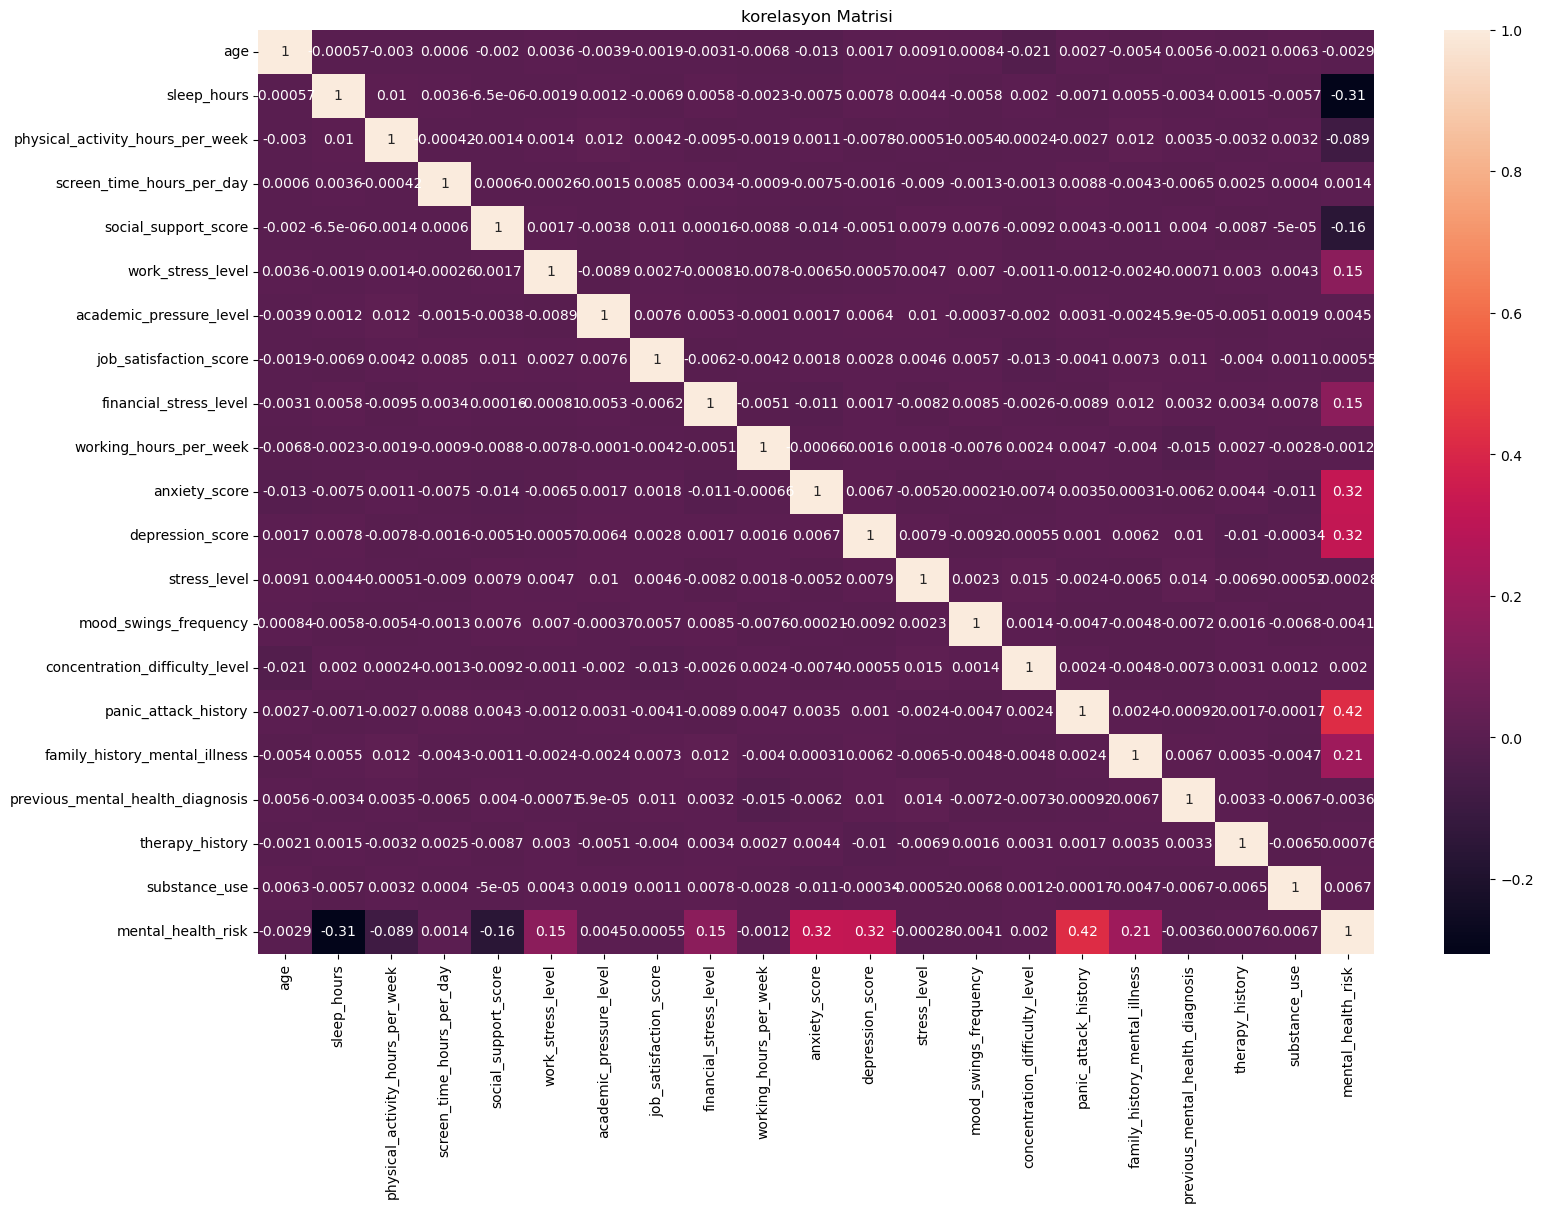

In [13]:
numeric_cols=data.select_dtypes(include=["int64","float64"]).columns
corr_matrix=data[numeric_cols].corr()

plt.figure(figsize=(18,12))
sns.heatmap(corr_matrix, annot=True)
plt.title("korelasyon Matrisi")
plt.show()

In [14]:
corr_matrix.loc[
    ["anxiety_score","depression_score","stress_level"],
    ["anxiety_score","depression_score","stress_level"]
]

,anxiety_score,depression_score,stress_level
anxiety_score,1.000000,0.006693,-0.005204
depression_score,0.006693,1.000000,0.007934
stress_level,-0.005204,0.007934,1.000000


In [15]:
X=data.drop("mental_health_risk", axis=1)
y=data["mental_health_risk"]

In [16]:
X_train, X_test, y_train, y_test= train_test_split(X,y,test_size=0.2,stratify=y)

In [19]:
import lightgbm as lgb
from sklearn.metrics import classification_report, confusion_matrix


In [20]:
model=lgb.LGBMClassifier(
    objective="multiclass",
    num_class=3,
    n_estimators=500,
    learning_rate=0.05,
    random_state=42
)
model.fit(
    X_train,
    y_train,
    categorical_feature=cat_cols
    
)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000796 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 569
[LightGBM] [Info] Number of data points in the train set: 20000, number of used features: 24
[LightGBM] [Info] Start training from score -0.982698
[LightGBM] [Info] Start training from score -0.748871
[LightGBM] [Info] Start training from score -1.878625


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.05
,n_estimators,500
,subsample_for_bin,200000
,objective,'multiclass'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [21]:
y_pred = model.predict(X_test)
print("--- Karışıklık Matrisi ---")
print(confusion_matrix(y_test, y_pred))
print("--- Sınıflandırma Raporu ---")
print(classification_report(y_test, y_pred))

--- Karışıklık Matrisi ---
[[1871    0    0]
 [   1 2364    0]
 [   0    5  759]]
--- Sınıflandırma Raporu ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1871
           1       1.00      1.00      1.00      2365
           2       1.00      0.99      1.00       764

    accuracy                           1.00      5000
   macro avg       1.00      1.00      1.00      5000
weighted avg       1.00      1.00      1.00      5000



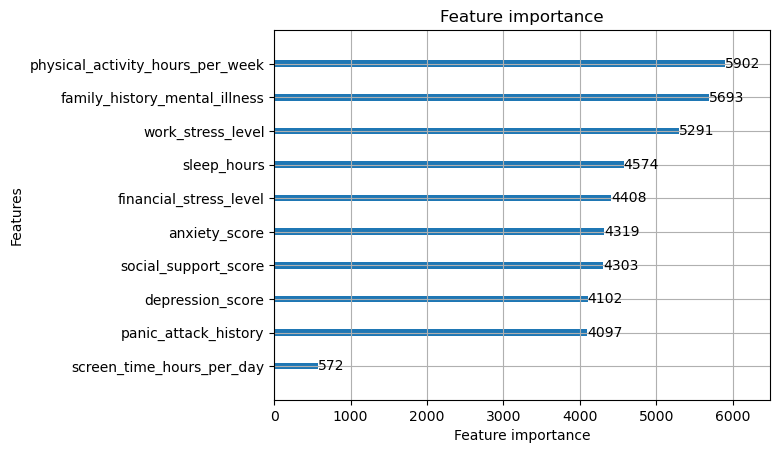

In [22]:
lgb.plot_importance(model, max_num_features=10)
plt.show()